In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import pickle

# Подготовка данных

In [55]:
data = pd.read_csv("../data/creditcard.csv")
data['amount_scaled'] = RobustScaler().fit_transform(data[['Amount']])
data['time_scaled'] = MinMaxScaler().fit_transform(data[['Time']])
data.drop(['Time', 'Amount'], axis=1, inplace=True)

In [56]:
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=.5, random_state=42)

In [57]:
len(X_train), len(X_val), len(X_test)

(227845, 28481, 28481)

In [58]:
y_train.value_counts(), y_val.value_counts(), y_test.value_counts()

(Class
 0    227451
 1       394
 Name: count, dtype: int64,
 Class
 0    28426
 1       55
 Name: count, dtype: int64,
 Class
 0    28438
 1       43
 Name: count, dtype: int64)

# Логистическая регрессия

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     28426
       fraud       0.82      0.58      0.68        55

    accuracy                           1.00     28481
   macro avg       0.91      0.79      0.84     28481
weighted avg       1.00      1.00      1.00     28481



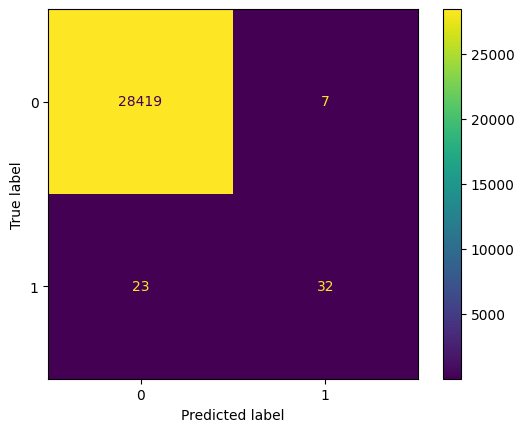

In [59]:
model = LogisticRegression()
model.fit(X_train, y_train)
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

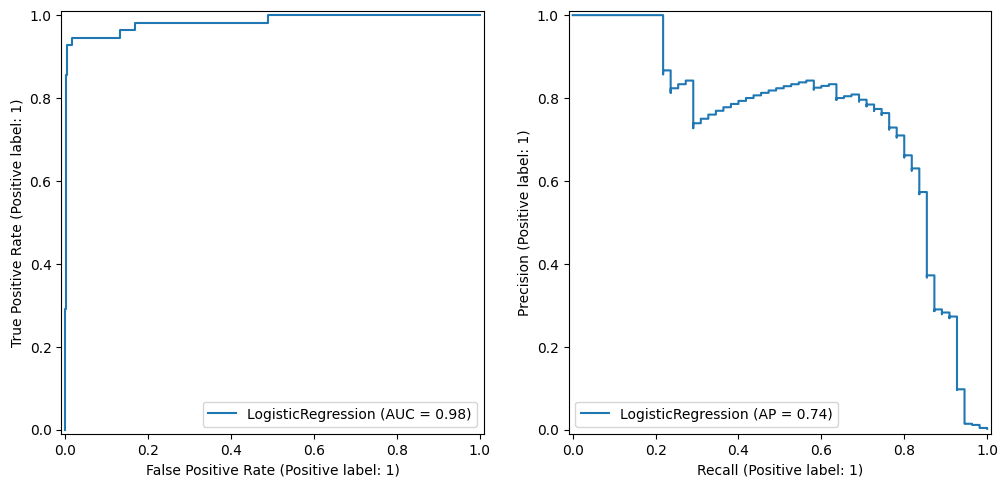

In [60]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax[0])
PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=ax[1])

### Базовая модель ожидаемо переобучилась на мажорантном классе, и пропускает очень много fraud классов

Дерево решений

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     28426
       fraud       0.81      0.80      0.81        55

    accuracy                           1.00     28481
   macro avg       0.91      0.90      0.90     28481
weighted avg       1.00      1.00      1.00     28481



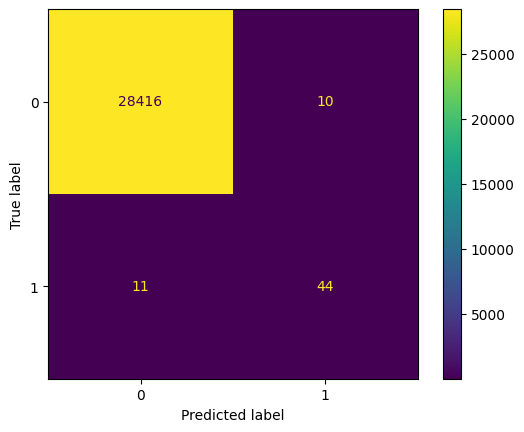

In [61]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)
print(classification_report(y_val, model.predict(X_val), target_names=['non-fraud', 'fraud']))
ConfusionMatrixDisplay(confusion_matrix(y_val, model.predict(X_val))).plot()

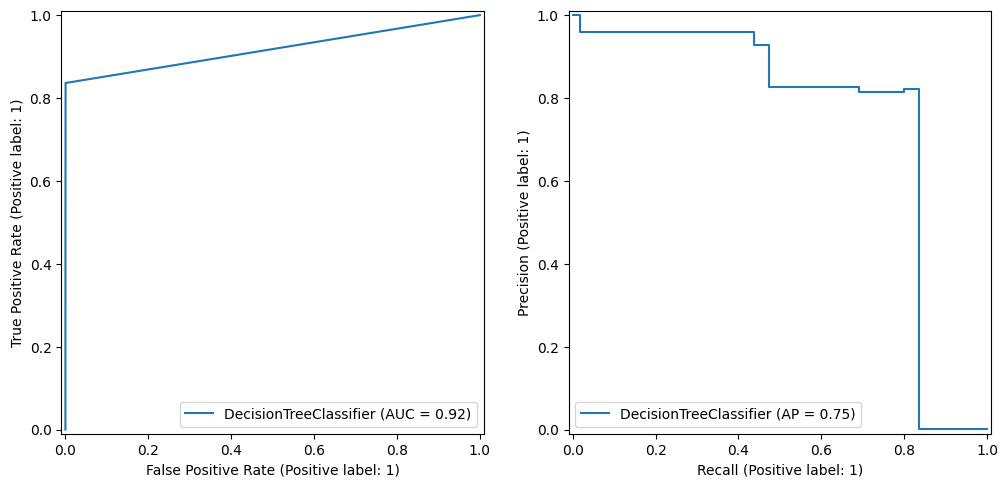

In [62]:
fig, ax = plt.subplots(1,2, figsize=(12,8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax[0])
PrecisionRecallDisplay.from_estimator(model, X_val, y_val, ax=ax[1])

### Дерево решений с ограничением на глубину имеет более высокий recall.

In [67]:
with open("../models/baseline.pkl", "wb") as f:
    pickle.dump(model, f)

# Заключение

- логистическая регрессия недостаточна для данного набора данных
- дерево решений с ограничением на глубину показало неплохой recall и f1. 
- датасет необычный, и требует необычных подходов к работе с данными
- для получения лучших результатов стоит попробовать андерсэмплинг (tomek links, nearmiss3)
- однозначно не стоит использовать smote (fraud класс слишком малочисленен)